In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, ClassifierMixin      # classifier, not regressor
from sklearn.model_selection import (RandomizedSearchCV, StratifiedKFold,
                                     cross_val_predict, cross_val_score,
                                     learning_curve)
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, RocCurveDisplay,
                              ConfusionMatrixDisplay, accuracy_score, f1_score)
from scipy.stats import uniform, randint
from catboost import CatBoostClassifier                      # classifier, not regressor

In [2]:
data = pd.read_csv('/home/ramir713/repos/PublicationAnalysis/data/machine_learning_data/data_ready_for_ml')

In [5]:
data.primary_field_name.value_counts()

primary_field_name
Agricultural and Biological Sciences            2225
Environmental Science                           1195
Engineering                                      121
Earth and Planetary Sciences                      86
Biochemistry, Genetics and Molecular Biology      78
Economics, Econometrics and Finance               35
Materials Science                                 33
Medicine                                          29
Social Sciences                                   24
Computer Science                                  22
Nursing                                           21
Energy                                            19
Business, Management and Accounting               17
Chemistry                                         13
Decision Sciences                                 12
Arts and Humanities                                7
Health Professions                                 6
Chemical Engineering                               4
Immunology and Microbiology

In [ ]:

columns_to_drop = [
 'openalex_id','Unnamed: 0','doi',
    'openalex_url',
    'title',
    'cited_by_count', 'fwci', 'citation_percentile_value',
    'queried_author_raw_name', 'queried_author_raw_affiliation',
    'source_display_name', 'source_issn_l', 'source_issn',
    'source_host_org_name',
    'primary_topic_name',
    'primary_subfield_name',
    'primary_field_name',
    'all_topics', 'sdg_names','source_type', 'is_oa', 'queried_author_is_corresponding', 'source_is_oa',
    'sustainable_development_goals',
    'referenced_works', 'related_works','apc_paid_value_usd',
    'sdg_names_list','publication_date','primary_topic_score','citations_year_1_exact', 'citations_year_2_exact',
]
data.drop(columns=columns_to_drop, inplace=True)
data.columns

Index(['publication_year', 'type', 'authors_count', 'countries_distinct_count',
       'institutions_distinct_count', 'corresponding_author_ids',
       'corresponding_institution_ids', 'queried_author_id',
       'queried_author_position', 'oa_status', 'source_id',
       'apc_list_value_usd', 'primary_topic_id', 'primary_subfield_id',
       'primary_field_id', 'referenced_works_count',
       'citations_first_2y_exact'],
      dtype='str')

In [88]:
# ── Target ────────────────────────────────────────────────────────────────────
threshold = data['citations_first_2y_exact'].quantile(0.75)
data['is_high_impact'] = (data['citations_first_2y_exact'] >= threshold).astype(int)

print(f"Impact threshold   : {threshold:.0f} citations in first 2 years")
print(f"High impact papers : {data['is_high_impact'].sum()}")
print(f"Low  impact papers : {(data['is_high_impact'] == 0).sum()}")


Impact threshold   : 21 citations in first 2 years
High impact papers : 1019
Low  impact papers : 2940


In [57]:
from sklearn.base import BaseEstimator, ClassifierMixin
from catboost import CatBoostClassifier
import numpy as np

class CatBoostSklearnWrapper(BaseEstimator, ClassifierMixin):
    _estimator_type = "classifier"
    def __init__(self, cat_features=None, iterations=500, learning_rate=0.03,
                 depth=5, l2_leaf_reg=50, bagging_temperature=1.5,
                 min_data_in_leaf=50, subsample=0.7, colsample_bylevel=0.6,
                 random_seed=42, thread_count=4, verbose=0):
        self.cat_features        = cat_features
        self.iterations          = iterations
        self.learning_rate       = learning_rate
        self.depth               = depth
        self.l2_leaf_reg         = l2_leaf_reg
        self.bagging_temperature = bagging_temperature
        self.min_data_in_leaf    = min_data_in_leaf
        self.subsample           = subsample
        self.colsample_bylevel   = colsample_bylevel
        self.random_seed         = random_seed
        self.thread_count        = thread_count
        self.verbose             = verbose


    def fit(self, X, y):
        self.model_ = CatBoostClassifier(
            cat_features          = self.cat_features,
            iterations            = self.iterations,
            learning_rate         = self.learning_rate,
            depth                 = self.depth,
            l2_leaf_reg           = self.l2_leaf_reg,
            bagging_temperature   = self.bagging_temperature,
            min_data_in_leaf      = self.min_data_in_leaf,
            subsample             = self.subsample,
            colsample_bylevel     = self.colsample_bylevel,
            random_seed           = self.random_seed,
            thread_count          = self.thread_count,
            verbose               = self.verbose
        )
        self.model_.fit(X, y)
        self.classes_ = np.array([0, 1])
        return self

    def predict(self, X):
        return self.model_.predict(X).astype(int)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)

    def get_feature_importance(self):
        return self.model_.get_feature_importance()

In [58]:
# ── Features ──────────────────────────────────────────────────────────────────
numeric_cols = ['authors_count', 'countries_distinct_count', 'institutions_distinct_count',
                'apc_list_value_usd', 'referenced_works_count', 'publication_year']

cat_cols = ['type', 'queried_author_position', 'oa_status',
            'primary_topic_id', 'primary_subfield_id', 'primary_field_id',
            'source_id', 'corresponding_author_ids',
            'corresponding_institution_ids', 'queried_author_id']

X        = data[numeric_cols + cat_cols].copy()
y_target = data['is_high_impact'].copy()
X[cat_cols] = X[cat_cols].astype(str).fillna('missing')

In [59]:
# ── Preprocessor ──────────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', numeric_cols),
    ('cat', 'passthrough', cat_cols)
])

cat_feature_indices = list(range(len(numeric_cols), len(numeric_cols) + len(cat_cols)))


In [60]:
# ── Pipeline ──────────────────────────────────────────────────────────────────
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', CatBoostSklearnWrapper(cat_features=cat_feature_indices))
])

In [61]:
from sklearn.model_selection import StratifiedKFold
param_distributions = {
    'model__iterations':          randint(300, 1000),
    'model__learning_rate':       uniform(0.005, 0.05),
    'model__depth':               randint(4,9),
    'model__l2_leaf_reg':         randint(10,50),
    'model__bagging_temperature': uniform(0.5, 2.0),
    'model__min_data_in_leaf':    randint(20,100),
    'model__subsample':            uniform(0.6, 0.4),
    'model__colsample_bylevel':    uniform(0.6, 0.4),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
from sklearn.metrics import (classification_report, roc_auc_score,confusion_matrix, RocCurveDisplay)
from sklearn.model_selection import cross_val_predict

y_target = data['is_high_impact']

# Update scoring in RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator           = pipeline,
    param_distributions = param_distributions,
    n_iter              = 200,
    cv                  = cv,
    scoring             = 'roc_auc',  
    n_jobs              = 1,
    verbose             = 2,
    random_state        = 42,
    refit               = True
)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV] END model__bagging_temperature=1.249080237694725, model__colsample_bylevel=0.9802857225639665, model__depth=6, model__iterations=371, model__l2_leaf_reg=30, model__learning_rate=0.012800932022121826, model__min_data_in_leaf=94, model__subsample=0.7836995567863468; total time=   1.4s
[CV] END model__bagging_temperature=1.249080237694725, model__colsample_bylevel=0.9802857225639665, model__depth=6, model__iterations=371, model__l2_leaf_reg=30, model__learning_rate=0.012800932022121826, model__min_data_in_leaf=94, model__subsample=0.7836995567863468; total time=   1.6s
[CV] END model__bagging_temperature=1.249080237694725, model__colsample_bylevel=0.9802857225639665, model__depth=6, model__iterations=371, model__l2_leaf_reg=30, model__learning_rate=0.012800932022121826, model__min_data_in_leaf=94, model__subsample=0.7836995567863468; total time=   1.6s
[CV] END model__bagging_temperature=1.249080237694725, model__colsamp

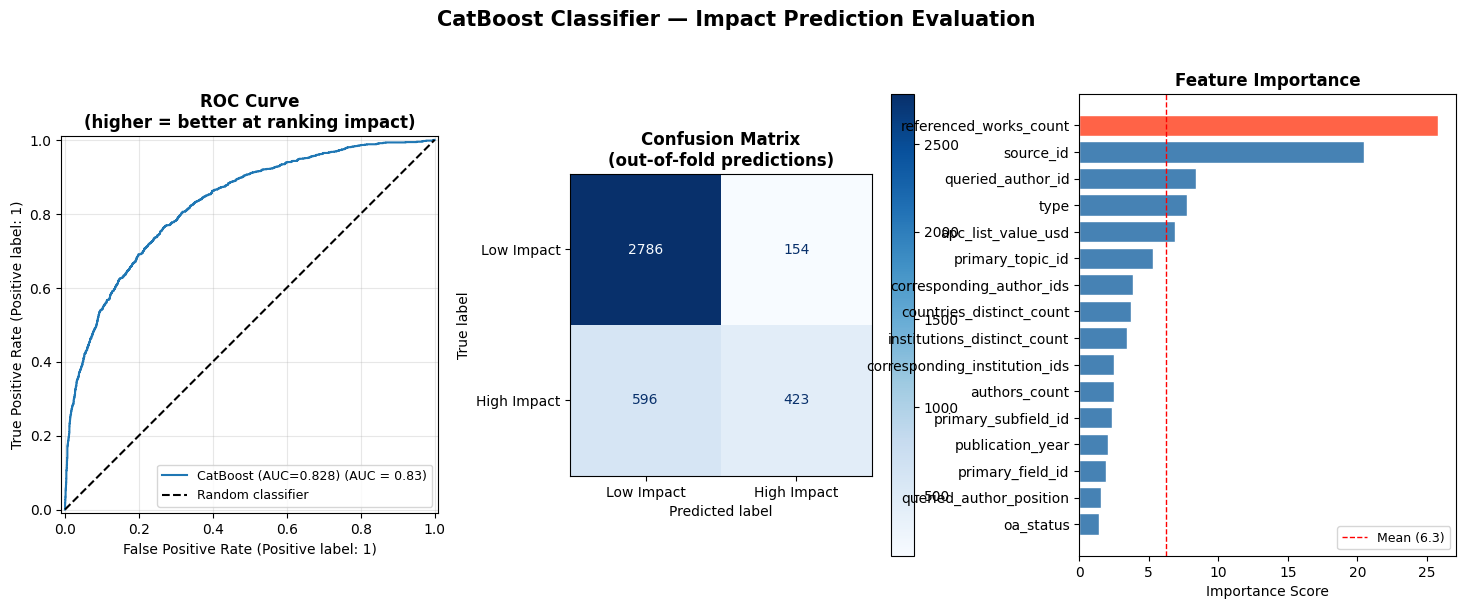

In [64]:
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, RocCurveDisplay,
                              ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_predict, cross_val_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

# ── Fit ───────────────────────────────────────────────────────────────────────
random_search.fit(X, y_target)
best_pipeline = random_search.best_estimator_

# ── Best Parameters ───────────────────────────────────────────────────────────
print("=" * 55)
print("BEST PARAMETERS")
print("=" * 55)
for param, value in random_search.best_params_.items():
    print(f"  {param.replace('model__', ''):<25} {value}")
print(f"\n  Best CV ROC-AUC : {random_search.best_score_:.4f}")
print("=" * 55)

# ── Out-of-Fold Predictions ───────────────────────────────────────────────────
oof_preds = cross_val_predict(best_pipeline, X, y_target, cv=cv)
oof_proba = cross_val_predict(best_pipeline, X, y_target, cv=cv,
                               method='predict_proba')[:, 1]

# ── Metrics ───────────────────────────────────────────────────────────────────
roc_auc = roc_auc_score(y_target, oof_proba)
cv_aucs = cross_val_score(best_pipeline, X, y_target, cv=cv, scoring='roc_auc')
cv_accs = cross_val_score(best_pipeline, X, y_target, cv=cv, scoring='accuracy')

print("\nOUT-OF-FOLD CLASSIFICATION METRICS")
print("=" * 55)
print(classification_report(y_target, oof_preds,
                             target_names=['Low Impact', 'High Impact']))
print(f"  ROC-AUC : {roc_auc:.4f}")
print(f"  CV AUC  : {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}")
print("=" * 55)

# ── Feature Importance ────────────────────────────────────────────────────────
feature_names = numeric_cols + cat_cols
importances   = best_pipeline.named_steps['model'].get_feature_importance()
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=True)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# — Plot 1: ROC Curve —
ax1 = fig.add_subplot(gs[0])
RocCurveDisplay.from_predictions(
    y_target, oof_proba,
    name = f'CatBoost (AUC={roc_auc:.3f})',
    ax   = ax1
)
ax1.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax1.set_title('ROC Curve\n(higher = better at ranking impact)',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# — Plot 2: Confusion Matrix —
ax2 = fig.add_subplot(gs[1])
ConfusionMatrixDisplay.from_predictions(
    y_target, oof_preds,
    display_labels = ['Low Impact', 'High Impact'],
    cmap           = 'Blues',
    ax             = ax2
)
ax2.set_title('Confusion Matrix\n(out-of-fold predictions)',
              fontsize=12, fontweight='bold')

# — Plot 3: Feature Importance —
ax3 = fig.add_subplot(gs[2])
colors = ['tomato' if imp == importances.max() else 'steelblue'
          for imp in importance_df['importance']]
ax3.barh(importance_df['feature'], importance_df['importance'],
         color=colors, edgecolor='white')
ax3.axvline(x=importances.mean(), color='red', linestyle='--',
            linewidth=1, label=f'Mean ({importances.mean():.1f})')
ax3.set_title('Feature Importance', fontsize=12, fontweight='bold')
ax3.set_xlabel('Importance Score')
ax3.legend(fontsize=9)

fig.suptitle('CatBoost Classifier — Impact Prediction Evaluation',
             fontsize=15, fontweight='bold', y=1.02)
plt.savefig('classifier_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [76]:
# # ── 1. Train vs CV Score Comparison ───────────────────────────────────────────
# best_pipeline = random_search.best_estimator_

# train_proba   = best_pipeline.predict_proba(X)[:, 1]
# train_preds   = best_pipeline.predict(X)
# train_auc     = roc_auc_score(y_target, train_proba)
# train_acc     = accuracy_score(y_target, train_preds)

# cv_aucs = cross_val_score(best_pipeline, X, y_target, cv=cv,
#                           scoring='roc_auc', error_score='raise')
# cv_accs       = cross_val_score(best_pipeline, X, y_target, cv=cv, scoring='accuracy')

# print("=" * 60)
# print("OVERFITTING / UNDERFITTING DIAGNOSTICS")
# print("=" * 60)
# print(f"\n  {'Metric':<25} {'Train':>10} {'CV (mean)':>12} {'CV (std)':>10}")
# print(f"  {'-'*57}")
# print(f"  {'ROC-AUC':<25} {train_auc:>10.4f} {cv_aucs.mean():>12.4f} {cv_aucs.std():>10.4f}")
# print(f"  {'Accuracy':<25} {train_acc:>10.4f} {cv_accs.mean():>12.4f} {cv_accs.std():>10.4f}")

# gap = train_auc - cv_aucs.mean()
# print(f"\n  Train vs CV AUC gap : {gap:.4f}")
# if gap < 0.03:
#     verdict = "✅ No overfitting — train and CV scores are very close"
# elif gap < 0.08:
#     verdict = "⚠️  Mild overfitting — small but acceptable gap"
# else:
#     verdict = "❌ Overfitting — large gap between train and CV"
# print(f"  Verdict             : {verdict}")
# print("=" * 60)

In [81]:
from sklearn.metrics import f1_score, classification_report

# ── F1 Scores (out-of-fold — honest estimate) ─────────────────────────────────
f1_high   = f1_score(y_target, oof_preds, pos_label=1)
f1_low    = f1_score(y_target, oof_preds, pos_label=0)
f1_macro  = f1_score(y_target, oof_preds, average='macro')
f1_weighted = f1_score(y_target, oof_preds, average='weighted')

print("=" * 55)
print("F1 SCORES (out-of-fold)")
print("=" * 55)
print(f"  High Impact (class 1) : {f1_high:.4f}")
print(f"  Low  Impact (class 0) : {f1_low:.4f}")
print(f"  Weighted average      : {f1_weighted:.4f}")
print("=" * 55)
print(f"\n   {y_target.sum()} high impact vs "
      f"{(y_target==0).sum()} low impact papers.")
print(f"  →  F1 ({f1_weighted:.4f})  score.")

F1 SCORES (out-of-fold)
  High Impact (class 1) : 0.5301
  Low  Impact (class 0) : 0.8814
  Weighted average      : 0.7909

   1019 high impact vs 2940 low impact papers.
  →  F1 (0.7909)  score.


Computing SHAP values...
Done ✓


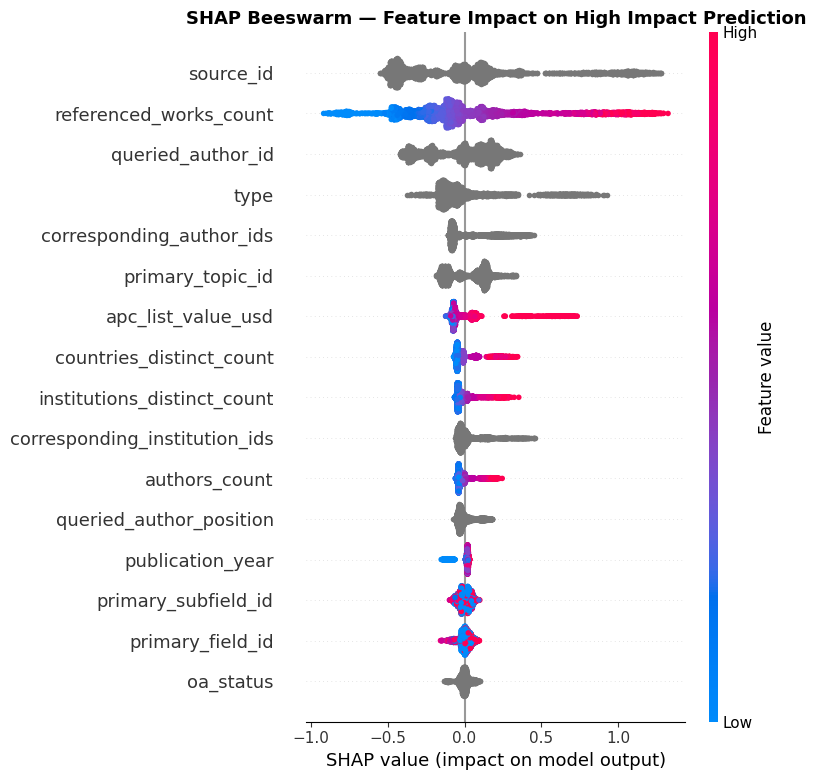

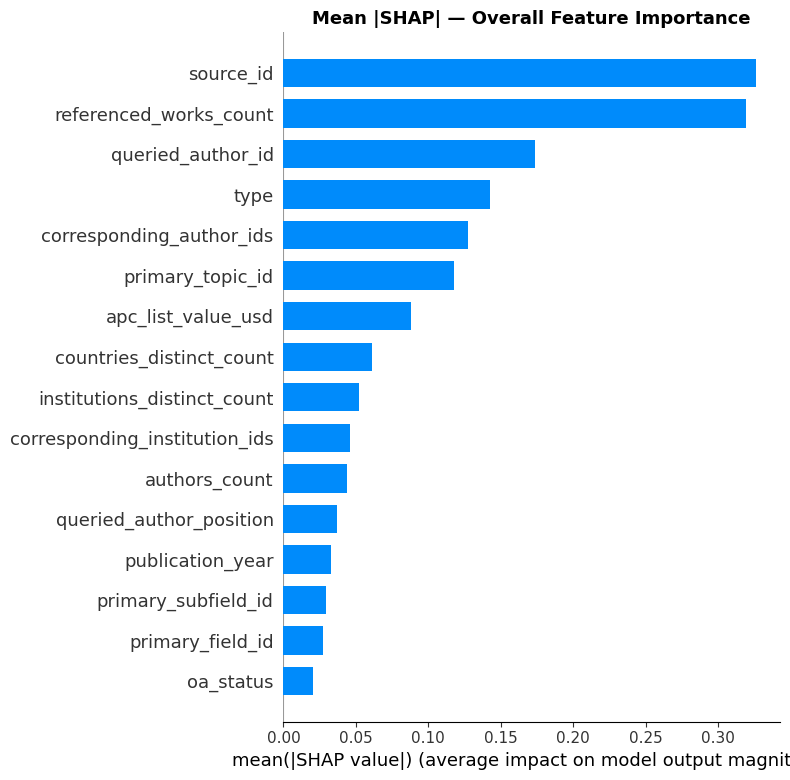

In [84]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ── Setup ─────────────────────────────────────────────────────────────────────
best_pipeline  = random_search.best_estimator_
catboost_model = best_pipeline.named_steps['model'].model_
preprocessor   = best_pipeline.named_steps['preprocessor']

feature_names    = numeric_cols + cat_cols
X_transformed_df = pd.DataFrame(preprocessor.transform(X), columns=feature_names)

# Use original X for color so numeric features are not object dtype
X_plot = X.copy()
X_plot[numeric_cols] = X_plot[numeric_cols].apply(pd.to_numeric, errors="coerce")

# ── Compute SHAP ──────────────────────────────────────────────────────────────
print("Computing SHAP values...")
explainer   = shap.TreeExplainer(catboost_model)
shap_values = explainer.shap_values(X_transformed_df)

# For binary classification, SHAP can return a list of arrays
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("Done ✓")

# ── Plot 1: Beeswarm — shows direction AND magnitude per feature ───────────────
plt.figure()
shap.summary_plot(shap_values, X_plot, show=False)
plt.title("SHAP Beeswarm — Feature Impact on High Impact Prediction",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Plot 2: Bar — mean absolute SHAP (global importance) ─────────────────────
plt.figure()
shap.summary_plot(shap_values, X_plot, plot_type='bar', show=False)
plt.title("Mean |SHAP| — Overall Feature Importance",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

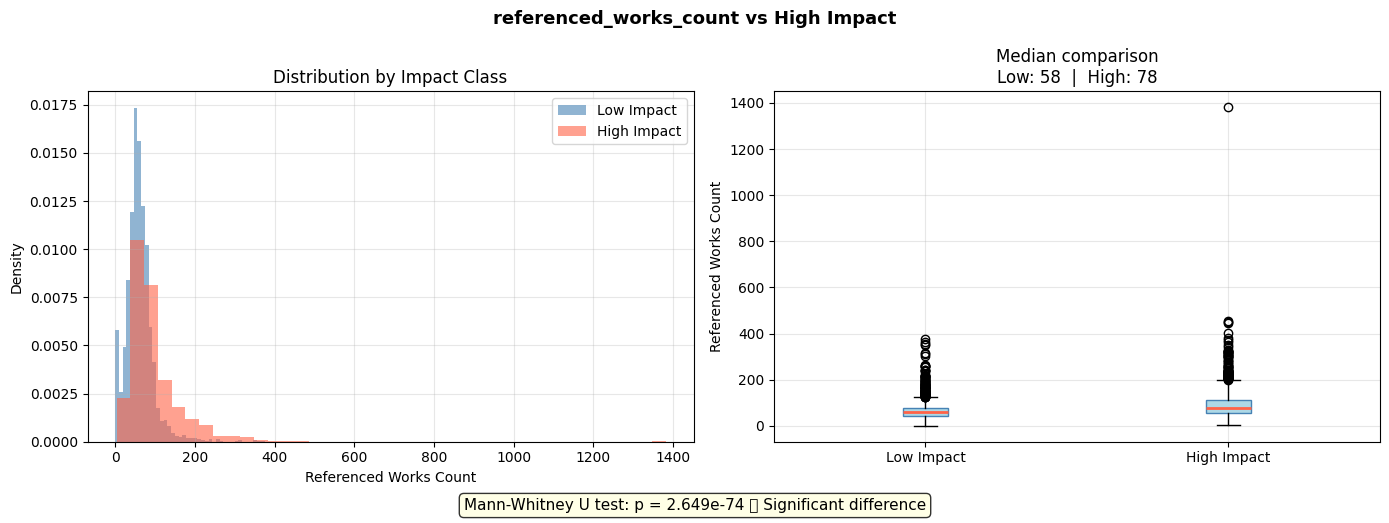

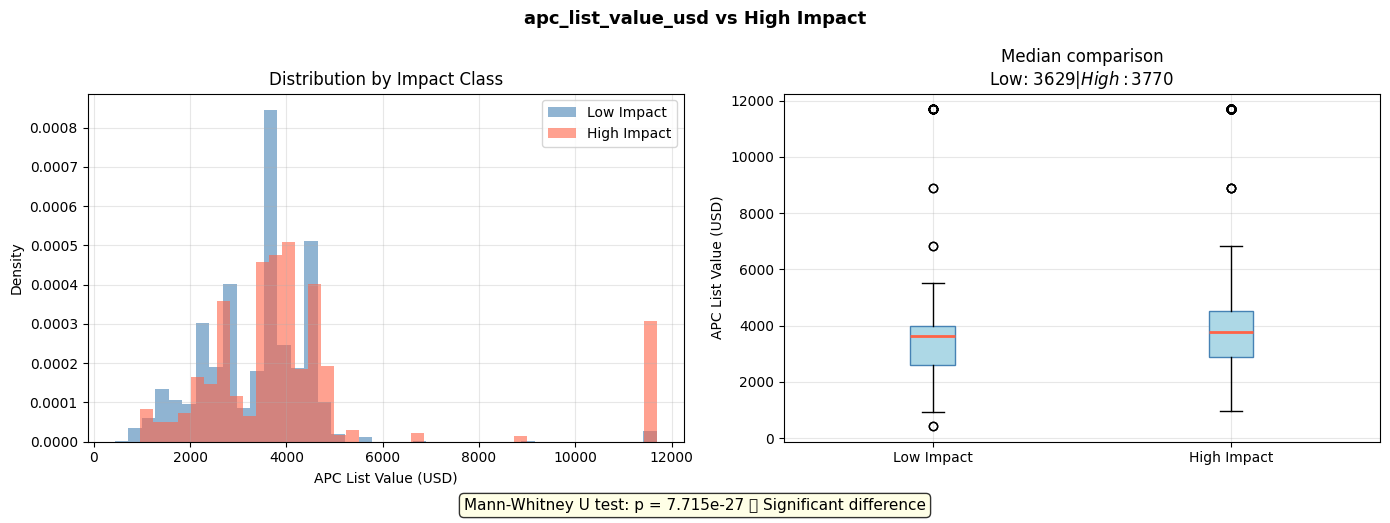

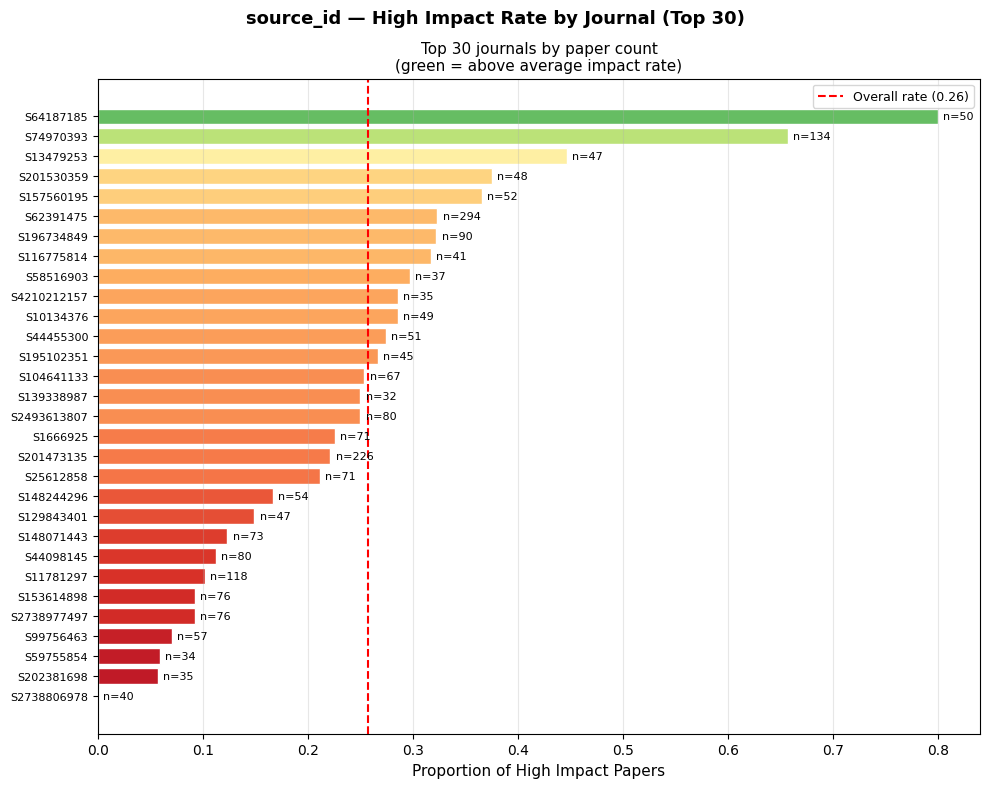

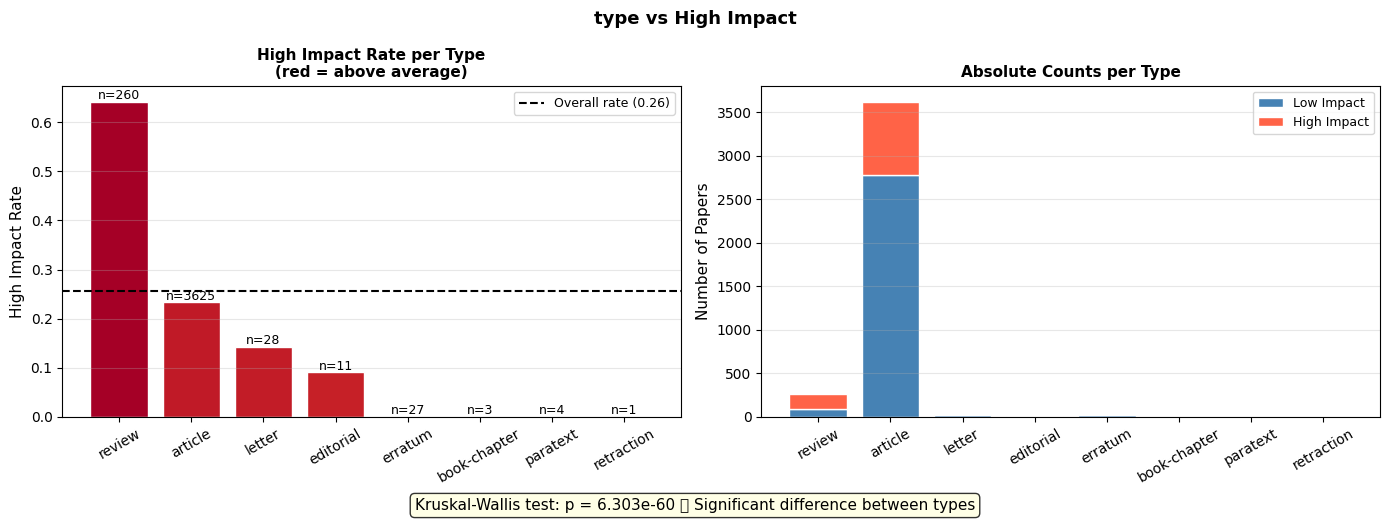

In [89]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
from scipy import stats

df_plot = data[['referenced_works_count', 'apc_list_value_usd',
                        'source_id', 'type',
                        'is_high_impact', 'citations_first_2y_exact']].copy()

# ── 1. referenced_works_count — numeric ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('referenced_works_count vs High Impact', fontsize=13, fontweight='bold')

low  = df_plot.loc[df_plot['is_high_impact'] == 0, 'referenced_works_count'].dropna()
high = df_plot.loc[df_plot['is_high_impact'] == 1, 'referenced_works_count'].dropna()

# Overlapping histograms
axes[0].hist(low,  bins=40, alpha=0.6, color='steelblue',
             density=True, label='Low Impact')
axes[0].hist(high, bins=40, alpha=0.6, color='tomato',
             density=True, label='High Impact')
axes[0].set_xlabel('Referenced Works Count')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution by Impact Class')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot side by side
axes[1].boxplot([low, high], labels=['Low Impact', 'High Impact'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='tomato', linewidth=2))
axes[1].set_ylabel('Referenced Works Count')
axes[1].set_title(f'Median comparison\n'
                  f'Low: {low.median():.0f}  |  High: {high.median():.0f}')
axes[1].grid(alpha=0.3)

stat, p = stats.mannwhitneyu(low, high, alternative='two-sided')
fig.text(0.5, -0.02,
         f'Mann-Whitney U test: p = {p:.3e} '
         f'{"✅ Significant difference" if p < 0.05 else "❌ No significant difference"}',
         ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.show()

# ── 2. apc_list_value_usd — numeric ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('apc_list_value_usd vs High Impact', fontsize=13, fontweight='bold')

low  = df_plot.loc[df_plot['is_high_impact'] == 0, 'apc_list_value_usd'].dropna()
high = df_plot.loc[df_plot['is_high_impact'] == 1, 'apc_list_value_usd'].dropna()

axes[0].hist(low,  bins=40, alpha=0.6, color='steelblue',
             density=True, label='Low Impact')
axes[0].hist(high, bins=40, alpha=0.6, color='tomato',
             density=True, label='High Impact')
axes[0].set_xlabel('APC List Value (USD)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution by Impact Class')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].boxplot([low, high], labels=['Low Impact', 'High Impact'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='tomato', linewidth=2))
axes[1].set_ylabel('APC List Value (USD)')
axes[1].set_title(f'Median comparison\n'
                  f'Low: ${low.median():.0f}  |  High: ${high.median():.0f}')
axes[1].grid(alpha=0.3)

stat, p = stats.mannwhitneyu(low, high, alternative='two-sided')
fig.text(0.5, -0.02,
         f'Mann-Whitney U test: p = {p:.3e} '
         f'{"✅ Significant difference" if p < 0.05 else "❌ No significant difference"}',
         ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.show()

# ── 3. source_id — high cardinality categorical ────────────────────────────────
# Strategy: show top N journals by paper count, plot high-impact RATE per journal
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('source_id — High Impact Rate by Journal (Top 30)',
             fontsize=13, fontweight='bold')

source_stats = (df_plot.groupby('source_id')['is_high_impact']
                .agg(['mean', 'count'])
                .rename(columns={'mean': 'high_impact_rate', 'count': 'n_papers'})
                .reset_index())

# Only journals with enough papers to be meaningful
source_stats = source_stats[source_stats['n_papers'] >= 5]
top30 = source_stats.nlargest(30, 'n_papers').sort_values('high_impact_rate')

# Color bars by rate — red = high impact journals, blue = low
colors = plt.cm.RdYlGn(top30['high_impact_rate'].values)
bars   = ax.barh(range(len(top30)), top30['high_impact_rate'],
                 color=colors, edgecolor='white')

# Add paper count labels
for i, (_, row) in enumerate(top30.iterrows()):
    ax.text(row['high_impact_rate'] + 0.005, i,
            f"n={row['n_papers']:.0f}", va='center', fontsize=8)

ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30['source_id'], fontsize=8)
ax.axvline(x=df_plot['is_high_impact'].mean(), color='red',
           linestyle='--', linewidth=1.5,
           label=f'Overall rate ({df_plot["is_high_impact"].mean():.2f})')
ax.set_xlabel('Proportion of High Impact Papers', fontsize=11)
ax.set_title('Top 30 journals by paper count\n'
             '(green = above average impact rate)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ── 4. type — low cardinality categorical ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('type vs High Impact', fontsize=13, fontweight='bold')

type_stats = (df_plot.groupby('type')['is_high_impact']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'high_impact_rate', 'count': 'n_papers'})
              .reset_index()
              .sort_values('high_impact_rate', ascending=False))

# Bar chart of high impact rate per type
# colors = ['tomato' if r > df_plot['is_high_impact'].mean()
#           else 'steelblue' for r in type_stats['high_impact_rate']]
bars = axes[0].bar(type_stats['type'], type_stats['high_impact_rate'],
                   color=colors, edgecolor='white')
axes[0].axhline(y=df_plot['is_high_impact'].mean(), color='black',
                linestyle='--', linewidth=1.5,
                label=f'Overall rate ({df_plot["is_high_impact"].mean():.2f})')
for bar, (_, row) in zip(bars, type_stats.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'n={row["n_papers"]:.0f}',
                 ha='center', fontsize=9)
axes[0].set_ylabel('High Impact Rate', fontsize=11)
axes[0].set_title('High Impact Rate per Type\n(red = above average)',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

# Stacked bar showing absolute counts
low_counts  = df_plot[df_plot['is_high_impact'] == 0]['type'].value_counts()
high_counts = df_plot[df_plot['is_high_impact'] == 1]['type'].value_counts()
all_types   = type_stats['type']

axes[1].bar(all_types,
            [low_counts.get(t, 0) for t in all_types],
            label='Low Impact', color='steelblue', edgecolor='white')
axes[1].bar(all_types,
            [high_counts.get(t, 0) for t in all_types],
            bottom=[low_counts.get(t, 0) for t in all_types],
            label='High Impact', color='tomato', edgecolor='white')
axes[1].set_ylabel('Number of Papers', fontsize=11)
axes[1].set_title('Absolute Counts per Type', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

# Kruskal-Wallis test
groups  = [df_plot.loc[df_plot['type'] == t, 'citations_first_2y_exact'].dropna().values
           for t in all_types if len(df_plot[df_plot['type'] == t]) >= 5]
stat, p = stats.kruskal(*groups)
fig.text(0.5, -0.02,
         f'Kruskal-Wallis test: p = {p:.3e} '
         f'{"✅ Significant difference between types" if p < 0.05 else "❌ No significant difference"}',
         ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.show()

In [ ]:
data_dif = pd.read_csv('/home/ramir713/repos/PublicationAnalysis/data/machine_learning_data/data_ready_for_ml')
# Get top 5 journals by high impact rate
top_5_journals = source_stats.nlargest(5, 'high_impact_rate')

# Get journal names from original data using source_id
top_5_journals['journal_name'] = top_5_journals['source_id'].map(
    data_dif[['source_id', 'source_display_name']].drop_duplicates().set_index('source_id')['source_display_name']
)

# Display the results with key columns
print(top_5_journals[['source_id', 'journal_name', 'high_impact_rate', 'n_papers']])


       source_id             journal_name  high_impact_rate  n_papers
207    S48977010        Nature Geoscience          0.909091        11
73    S183584863    Nature Climate Change          0.875000        16
182  S4210207988              Nature Food          0.838710        31
225    S64187185    Nature Communications          0.800000        50
90    S201780205  Trends in Plant Science          0.750000         8
